# **Section 3: Principal Component Analysis and K-Means Clustering**

## **1. Principal Component Analysis**

Now that we have extracted and cleaned the CNV features, we can perform a dimensionality reduction step using a **Principal Component Analysis (PCA)**. A PCA reduces the number of dimensions by projecting the data onto a set of orthogonal axes called principal components. We can then select an optimal number of principal components that explain most of the variance in our dataset, which will reduce dimensionality while minimizing information loss.

We will use **scikit-learn** to perform the PCA and **k-means clustering** to group samples by their SNP profiles, then label them according to their resistance profile.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
sns.set_style('whitegrid')
sns.set_palette("pastel")

### **1.1 Load SNP Features and Resistance Profiles**

In [2]:
# Load SNP features
cnv_data = pd.read_csv('cnvs_cleaned_SXT.csv', index_col=0)
X = cnv_data.values
print(f"CNV data shape: {X.shape}")

CNV data shape: (221, 8085)


In [3]:
# Load resistance profile metadata
SXT = pd.read_csv('SXT.csv', index_col=0)
y = SXT.values
print(f"Resistance profile shape: {SXT.shape}")

Resistance profile shape: (221, 1)


### **1.2 Standardize the Data**

In [4]:
# Create and apply StandardScaler
scaler = StandardScaler()
X_rescaled = scaler.fit_transform(X)

print(f"Scaled data shape: {X_rescaled.shape}")
print(f"Mean of scaled features: {X_rescaled.mean(axis=0).mean()}")
print(f"Std of scaled features: {X_rescaled.std(axis=0).mean()}")

Scaled data shape: (221, 8085)
Mean of scaled features: 2.9050240866168066e-18
Std of scaled features: 1.0


### **1.3 Perform PCA**

In [5]:
# Create and fit PCA with all components
pca = PCA(n_components=None)
X_pca = pca.fit_transform(X_rescaled)

print(f"PCA transformed data shape: {X_pca.shape}")

PCA transformed data shape: (221, 221)


### **1.5 Scree Plot: Variance Explained by Components**

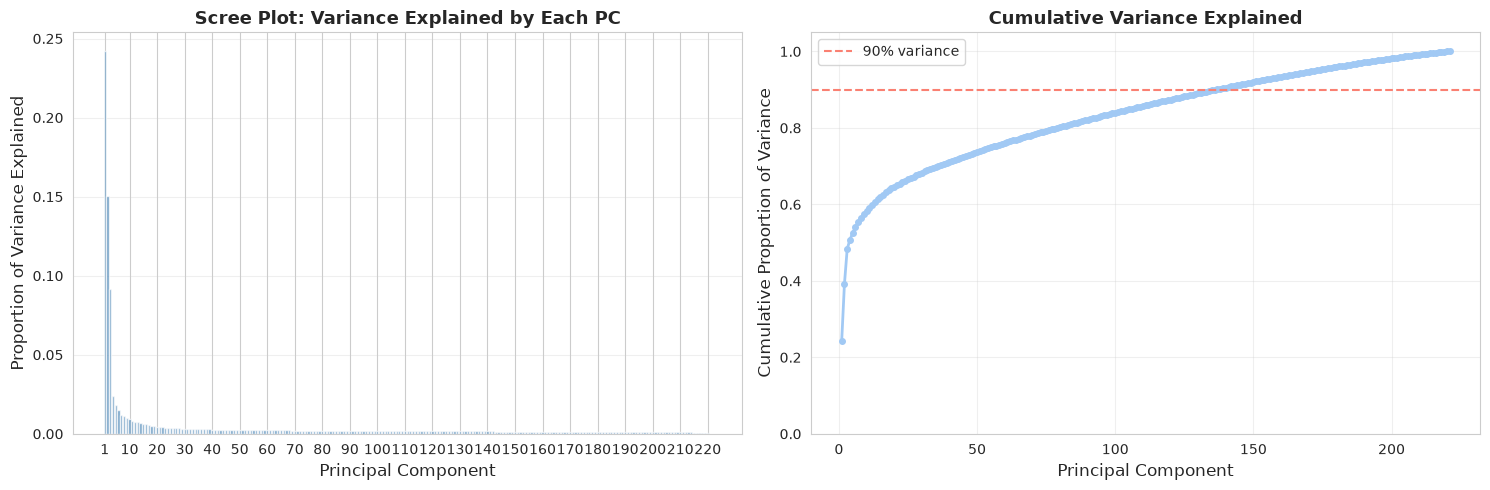

In [6]:
# Proportion of variance explained
pve = pca.explained_variance_ratio_
pve_cumsum = np.cumsum(pve)

# Create figure with scree plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Individual variance explained
components = np.arange(1, len(pve) + 1)
ax1.bar(components, pve, alpha=0.7, color='steelblue')
ax1.set_xticks([1] + list(np.arange(10, len(pve) + 1, 10)))
ax1.set_xlabel('Principal Component', fontsize=12)
ax1.set_ylabel('Proportion of Variance Explained', fontsize=12)
ax1.set_title('Scree Plot: Variance Explained by Each PC', fontsize=13, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Plot 2: Cumulative variance explained
ax2.plot(components, pve_cumsum, marker='o', linestyle='-', linewidth=2, markersize=4)
ax2.axhline(y=0.90, color='salmon', linestyle='--', label='90% variance')
ax2.set_xlabel('Principal Component', fontsize=12)
ax2.set_ylabel('Cumulative Proportion of Variance', fontsize=12)
ax2.set_title('Cumulative Variance Explained', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)
ax2.set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

### **1.6 Variance Explained Summary**

In [7]:
# Print variance explained per threshold
thresholds = [0.1, 0.2, 0.3, 0.5, 0.7, 0.8, 0.9, 0.95]
for threshold in thresholds:
    n_components = np.sum(pve_cumsum <= threshold)
    if n_components > 0:
        print(f"{int(n_components)} principal components explain {threshold*100:.0f}% of the variance")

print(f"\nFirst 2 PCs explain {pve_cumsum[1]*100:.2f}% of the variance")
print(f"First 3 PCs explain {pve_cumsum[2]*100:.2f}% of the variance")

1 principal components explain 30% of the variance
3 principal components explain 50% of the variance
35 principal components explain 70% of the variance
78 principal components explain 80% of the variance
136 principal components explain 90% of the variance
172 principal components explain 95% of the variance

First 2 PCs explain 39.20% of the variance
First 3 PCs explain 48.37% of the variance


### **1.7 Loading Vectors of First Two Components**

In [9]:
# Create DataFrame with the weights of the loading vectors for the first two principal components
feature_names = cnv_data.columns.tolist()

weights = pd.DataFrame(
    {
        "1st component": pca.components_[0],
        "2nd component": pca.components_[1],
    },
    index=feature_names
)

print("Top 5 features contributing to the 1st Principal Component:")
print(abs(weights).sort_values(by="1st component", ascending=False).head(5))

print("\nTop 5 features contributing to the 2nd Principal Component:")
print(abs(weights).sort_values(by="2nd component", ascending=False).head(5))

Top 5 features contributing to the 1st Principal Component:
                                             1st component  2nd component
cnv_depth__IBNLCO_03196__secY__gene               0.021579       0.000040
cnv_depth__IBNLCO_03224__DNA-directed__CDS        0.021561       0.004957
cnv_depth__IBNLCO_00001__IBNLCO_00001__gene       0.021554       0.000456
cnv_depth__IBNLCO_00245__IBNLCO_00245__gene       0.021533       0.003221
cnv_depth__IBNLCO_03219__IBNLCO_03219__gene       0.021505       0.004029

Top 5 features contributing to the 2nd Principal Component:
                                              1st component  2nd component
cnv_depth__IBNLCO_05762__Putative__CDS             0.002354       0.026444
cnv_depth__IBNLCO_03080__Heat__CDS__promoter       0.005460       0.026337
cnv_depth__IBNLCO_00795__IBNLCO_00795__gene        0.000118       0.026083
cnv_depth__IBNLCO_02918__Gluconate__CDS            0.000179       0.025906
cnv_depth__IBNLCO_05625__yxjC__gene                0.000537 

### **1.8 Data visualization**

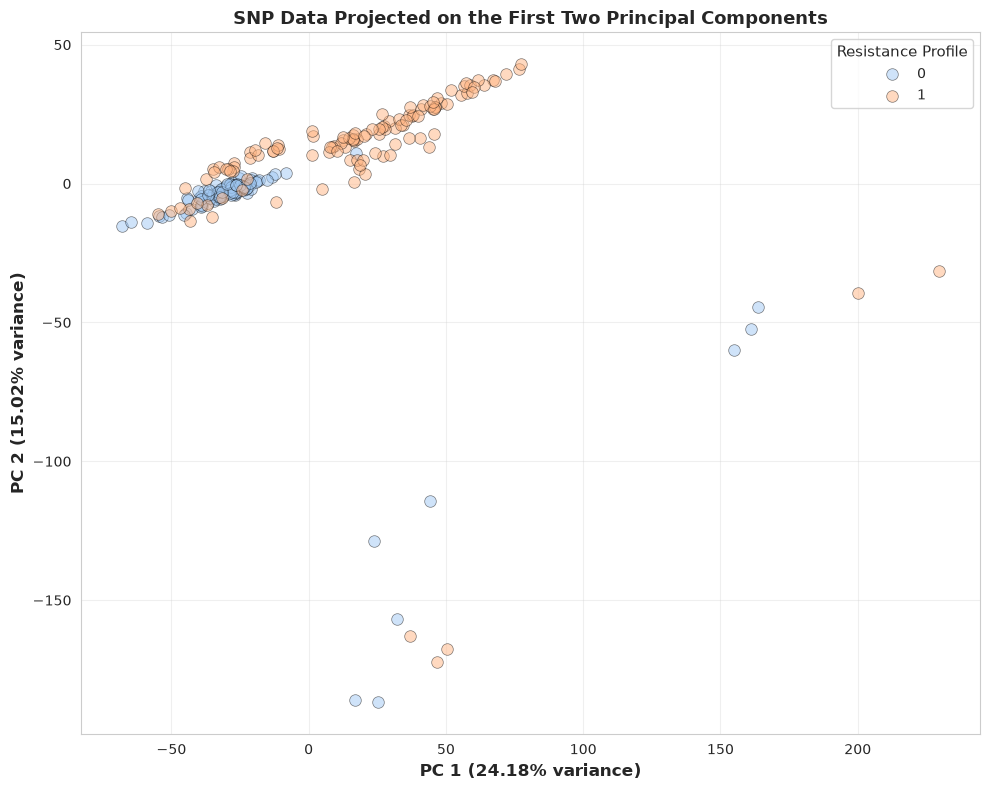

In [10]:
# Plot data projected onto first two PCs, colored by resistance profile
plt.figure(figsize=(10, 8))

profiles = np.unique(y)

for profile in profiles:
    idx = np.where(y == profile)[0]
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], label=profile, alpha=0.5, s=70, edgecolors='k', linewidth=0.5)

plt.xlabel(f'PC 1 ({pve[0]*100:.2f}% variance)', fontsize=12, fontweight='bold')
plt.ylabel(f'PC 2 ({pve[1]*100:.2f}% variance)', fontsize=12, fontweight='bold')
plt.title('SNP Data Projected on the First Two Principal Components', fontsize=13, fontweight='bold')
plt.legend(loc='best', fontsize=10, title='Resistance Profile', title_fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()